<a href="https://colab.research.google.com/github/Hamzeh05/NLP-Project/blob/main/NLP_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Loading the datasets**

In [19]:


%%writefile downloader_extractor_utils.py
from collections import namedtuple
from datetime import datetime
import json
import re
from urllib.parse import urlparse

import bs4
from bs4 import BeautifulSoup
import dateutil.parser
import dateutil.tz
import regex

DomainSettings = namedtuple("DomainSettings",
                            ["encoding",
                             "document_extractor",
                             "headline_extractor",
                             "date_extractor"
                            ]
                           )

month_str_to_num = {
    'يناير': 1,
    'فبراير': 2,
    'مارس': 3,
    'أبريل': 4,
    'مايو': 5,
    'يونيو': 6,
    'يوليو': 7,
    'أغسطس': 8,
    'سبتمبر': 9,
    'أكتوبر': 10,
    'نوفمبر': 11,
    'ديسمبر': 12,
}
def format_d(text):
  date_f = re.findall(r'\s(\d\d) \-(\d\d)\- (\d{4})', str(text))
  if date_f:
    year, month, day = int(date_f[0][2]), int(date_f[0][1]), int(date_f[0][0])
    return datetime(year, month, day)

  date_f = re.findall(r'\s(\d\d)/(\d\d)/(\d{4})', str(text))
  if date_f:
    year, month, day = int(date_f[0][2]), int(date_f[0][1]), int(date_f[0][0])
    return datetime(year, month, day)

  date_f = re.findall(r'(\d{2})\s(\w+)\s(\d{4})', str(text))
  if date_f:
    year, month_str, day = int(date_f[0][2]), date_f[0][1], int(date_f[0][0])
    return datetime(year, month_str_to_num[month_str], day)

  print('Error parsing date')

def fix_new_line(text):
  splits = text.split('\n')
  if len(splits) > 0:
    return splits[0]
  return text

def process_title_with_colon(text):
  splits = text.split(':')
  if len(splits) > 0:
    if splits[0].strip() == 'بالفيديو' or splits[0].strip() == 'بالصور':
      return splits[1].strip()
  return text

def process_title_with_dots(text):
  splits = text.split('..')
  if len(splits) > 0:
    if splits[0].strip() == 'بالفيديو' or splits[0].strip() == 'بالصور' or splits[0].strip() == 'شاهد':
      return splits[1].strip()
  return text

def extract_text_emaratalyoum(soup):
  for tag in soup.select('.metadata'):
    tag.extract()
  for tag in soup.select('script'):
    tag.extract()
  for tag in soup.select('.follow-google'):
    tag.extract()
  for tag in soup.select('.shareholder'):
    tag.extract()
  for tag in soup.select('#parsely-related-stories'):
    tag.extract()
  desc = soup.select("#articledetails")
  if len(desc) > 0:
    return desc[0].get_text().strip()
  return ''

def emaratalyoum_text_extractor(soup):
    text = extract_text_emaratalyoum(soup)
    text = fix_new_line(text)
    return text

def emaratalyoum_headline_extractor(soup):
    element = soup.find("meta", {"property":"og:title"})
    if element:
        text = process_title_with_colon(element['content'])
        text = process_title_with_dots(text)
        return text
    return ''

def almamlakatv_text_extractor(soup):
    text_container = soup.find('div', class_='article-body')
    if text_container:
        desc = text_container.find_all('p')[0].text
        desc = fix_new_line(desc.strip())
        return desc
    return ''

def almamlakatv_headline_extractor(soup):
    elements = soup.find_all('h1')
    if len(elements) > 0:
        return elements[0].text.strip()
    return ''

def emaratalyoum_date(soup):
    element = soup.find("meta", {"property":"article:published_time"})
    if element:
        return element['content']
    return ''

def almamlakatv_date(soup):
    time_elem = soup.find_all('time')
    if time_elem and len(time_elem)>0:
        return str(format_d(time_elem[0]))

domain_settings_dict = {
    'emaratalyoum.com': DomainSettings('utf-8',
                                 emaratalyoum_text_extractor,
                                 emaratalyoum_headline_extractor,
                                 emaratalyoum_date),
    'almamlakatv.com': DomainSettings('utf-8',
                                 almamlakatv_text_extractor,
                                 almamlakatv_headline_extractor,
                                 almamlakatv_date)
}

Overwriting downloader_extractor_utils.py


In [20]:
%%writefile downloader_extractor.py
import json
from urllib.parse import urlparse
from bs4 import BeautifulSoup
from downloader_extractor_utils import *

URL = 'url'
HEADLINE = 'headline'
TEXT = 'text'
SECTION = 'section'
SUBDOMAIN = 'subdomain'
FILENAME = 'filename'
OFFSET = 'offset'
LENGTH = 'length'
PUBLISHED = 'published'
DATASET = 'dataset'

class Extractor(object):
    @staticmethod
    def extract_document(input_document):
        parsed_content = Extractor._parse(input_document)
        return parsed_content

    @staticmethod
    def _parse(entry_dict):

        parsed_document = Extractor._parse_entry(entry_dict)

        for section_key in [HEADLINE, TEXT]:
            if parsed_document[section_key]:
                parsed_document[section_key].encode()
        return parsed_document

    @staticmethod
    def _parse_entry(contents):
        url = contents['url']
        parse = urlparse(url)
        domain = '.'.join(parse.netloc.rsplit('.', maxsplit=2)[-2:])
        subdomain = parse.netloc.replace('www.', '')
        if domain == subdomain:
            section = (parse.path.split('/') + [''])[1]
            if not section.isalnum():
                section = subdomain
        else:
            section = subdomain
            if 'blog' in section:
                section = 'blogs'

        domain_settings = domain_settings_dict.get(subdomain, domain_settings_dict.get(domain, None))

        warc = contents['content']
        html = warc.split('\r\n\r\n', maxsplit=2)[-1].replace('\r', '').replace('&nbsp;', ' ')
        soup = BeautifulSoup(html, 'html.parser')

        if domain_settings:
            headline_text = domain_settings.headline_extractor(soup)
            document_text = domain_settings.document_extractor(soup)
            published = domain_settings.date_extractor(soup)
        else:
            headline_text = ""
            document_text = ""
            published = ""

        if published is None: published = ""

        return {URL: url,
                HEADLINE: headline_text,
                TEXT: document_text,
                SECTION: section,
                SUBDOMAIN: subdomain,
                FILENAME: contents[FILENAME],
                OFFSET: contents[OFFSET],
                LENGTH: contents[LENGTH],
                PUBLISHED: published,
                DATASET: contents[DATASET]}

Overwriting downloader_extractor.py


In [21]:
%%writefile main_downloader.py
import argparse
import gzip
import json
import lzma
import multiprocessing.pool
import sys
import urllib.request
from downloader_extractor import Extractor

DATASETS = ["train", "valid", "test", "ood"]

parser = argparse.ArgumentParser()
parser.add_argument("--download_start", default=None, type=int, help="Index of the first element to download")
parser.add_argument("--download_end", default=None, type=int, help="Index of the last element to download")
parser.add_argument("--index_file", default="sumarabic-1.0-index.jsonl.xz", type=str, help="Name of the index file to use")
parser.add_argument("--parallel", default=16, type=int, help="Number of parallel processes to use")
parser.add_argument("--output_file", default="sumarabic-1.0-{}.jsonl", type=str, help="Output file name template to use")
args = parser.parse_args()

print("Loading the index file.", file=sys.stderr)
index = []
try:
    with lzma.LZMAFile(args.index_file, "r") as index_file:
        for line in index_file:
            index.append(json.loads(line.decode("utf-8")))
except FileNotFoundError:
    print(f"ERROR: {args.index_file} not found. Please upload it to Colab first.", file=sys.stderr)
    sys.exit(1)

print("Loading previously downloaded data.", file=sys.stderr)
datasets = {}
for dataset in DATASETS:
    datasets[dataset] = {
        "file": open(args.output_file.format(dataset), "a+", encoding="utf-8"),
        "downloaded": set()
    }
    datasets[dataset]["file"].seek(0)
    for i, line in enumerate(datasets[dataset]["file"]):
        assert line.endswith("\n"), "The last line of {} is not properly ended".format(args.output_file.format(dataset))
        try:
            entry = json.loads(line)
            datasets[dataset]["downloaded"].add(str(entry["filename"])+str(entry["offset"])+str(entry["length"]))
        except:
            raise ValueError("Cannot decode the line {} from {}".format(i + 1, args.output_file.format(dataset)))

def download_extract(entry):
    dataset = entry["dataset"]
    entry_id = str(entry["filename"])+str(entry["offset"])+str(entry["length"])
    if entry_id in datasets[dataset]["downloaded"]:
        return None

    tries = 0
    while True:
        try:
            with urllib.request.urlopen(urllib.request.Request(
                    "https://data.commoncrawl.org/{}".format(entry["filename"]),
                    headers={"Range": "bytes={}-{}".format(int(entry["offset"]), int(entry["offset"]) + int(entry["length"]) - 1)})) as response:
                with gzip.GzipFile(fileobj=response) as decompressed_response:
                    entry["content"] = decompressed_response.read().decode("utf-8")
            break
        except Exception as e:
            tries += 1
            if tries < 5:
                pass
            else:
                print("Too many errors during download of entry {}, aborting".format(entry), file=sys.stderr)
                return None

    extracted = Extractor.extract_document(entry)
    del entry["content"]
    return extracted

print("Downloading the data.", file=sys.stderr)
entries = index[args.download_start:args.download_end]

if args.parallel > 1:
    pool = multiprocessing.pool.Pool(args.parallel, initializer=lambda: sys.setrecursionlimit(1100))
    processed_entries = pool.imap(download_extract, entries)
else:
    processed_entries = map(download_extract, entries)

for i, processed_entry in enumerate(processed_entries):
    if processed_entry is not None:
        datasets[processed_entry["dataset"]]["file"].write(json.dumps(
            processed_entry, ensure_ascii=False, sort_keys=True, indent=None, separators=(", ", ": ")) + "\n")
    if (i + 1) % 10 == 0:
        print("Downloaded {}/{} documents.".format(i + 1, len(entries)), end="\r", file=sys.stderr, flush=True)

print("\nAll data downloaded successfully.", file=sys.stderr)

Overwriting main_downloader.py


In [22]:
!pip install beautifulsoup4 python-dateutil regex pandas
!python main_downloader.py --download_start 0 --download_end 100 --parallel 2

Loading the index file.
Loading previously downloaded data.
Downloaded 100/100 documents.
All data downloaded successfully.


In [23]:
import pandas as pd
import json

dataset_file = 'sumarabic-1.0-train.jsonl'
data = []

try:
    with open(dataset_file, 'r', encoding='utf-8') as f:
        for line in f:
            try:
                entry = json.loads(line)
                if entry.get('text') and entry.get('headline'):
                    data.append({
                        'document': entry['text'].strip(),
                        'summary': entry['headline'].strip(),
                        'source': entry['subdomain']
                    })
            except json.JSONDecodeError:
                continue

    df = pd.DataFrame(data)

    if not df.empty:
        df = df[(df['document'] != '') & (df['summary'] != '')]
        df.to_csv("arabic_summarization_dataset.csv", index=False, encoding='utf-8-sig')
        print(f"Successfully created dataset with {len(df)} rows!")
        display(df.head())
    else:
        print("Dataset is empty. The extracted documents might not have matched the two domains in the dictionary.")

except FileNotFoundError:
    print(f"Could not find {dataset_file}. Make sure Cell 4 completed successfully.")

Successfully created dataset with 94 rows!


,document,summary,source
0,اختتمت مساء أول من أمس نهائيات بطولة الإمارات ...,المصري فؤاد الطاهر بطل للشطرنج الديناميكي,emaratalyoum.com
1,مينيابوليس (الولايات المتحدة) 3-2-2008 (ا ف ب)...,"حملة انتخابية محمومة قبل ""الثلاثاء الكبير""",emaratalyoum.com
2,أفاد مصدر في شرطة أبوظبي بأن نحو 700 طفل يتواف...,55% من نزلاء «الأحداث» مواطنون,emaratalyoum.com
3,قال استشاري أمراض الكلى في مدينة الشيخ خليفة ا...,مركز متخصص في الكلى بمستشفى خليفة,emaratalyoum.com
4,بدأت القيادة العامة لشرطة أبوظبي التنسيق لإنشا...,تأهيل ضحايا حوادث المرور في أبوظبي,emaratalyoum.com


In [24]:
import pandas as pd
import zipfile
import glob
import warnings
from datasets import load_dataset, utils

warnings.filterwarnings('ignore')

print("Starting Master Data Merge...\n")


try:
    df_sumarabic = pd.read_csv("arabic_summarization_dataset.csv")
    df_sumarabic = df_sumarabic[['document', 'summary']]
    df_sumarabic['source_dataset'] = 'SumArabic'

except Exception as e:

    df_sumarabic = pd.DataFrame(columns=['document', 'summary', 'source_dataset'])


try:
    with zipfile.ZipFile('AbsArSumCorpus_csv_v1.zip', 'r') as zip_ref:
        zip_ref.extractall('arasum_extracted')
    arasum_csv_path = glob.glob('arasum_extracted/**/*.csv', recursive=True)[0]
    df_arasum = pd.read_csv(arasum_csv_path, sep="\t", header=None, names=["document", "summary"]).dropna()
    df_arasum['source_dataset'] = 'AraSum'

except Exception as e:

    df_arasum = pd.DataFrame(columns=['document', 'summary', 'source_dataset'])


try:
    utils.logging.disable_progress_bar()
    dataset = load_dataset("Omar-youssef/Egyptian-text-summarization", split="train", verification_mode="no_checks")
    df_egyptian = dataset.to_pandas().rename(columns={'text': 'document', 'summarized_text': 'summary'})[['document', 'summary']].dropna()
    df_egyptian['source_dataset'] = 'Egyptian'

except Exception as e:

    df_egyptian = pd.DataFrame(columns=['document', 'summary', 'source_dataset'])


try:
    with zipfile.ZipFile('summarizdataset.csv.zip', 'r') as zip_ref:
        zip_ref.extractall('kaggle_extracted')
    kaggle_csv_path = glob.glob('kaggle_extracted/**/summarizdataset.csv', recursive=True)[0]
    df_kaggle = pd.read_csv(kaggle_csv_path).rename(columns={'text': 'document', 'summarizer': 'summary'})[['document', 'summary']].dropna()
    df_kaggle['source_dataset'] = 'Kaggle'

except Exception as e:

    df_kaggle = pd.DataFrame(columns=['document', 'summary', 'source_dataset'])


print("\nMerging datasets...")
master_df = pd.concat([df_sumarabic, df_arasum, df_egyptian, df_kaggle], ignore_index=True)


master_df['document'] = master_df['document'].astype(str)
master_df['summary'] = master_df['summary'].astype(str)
master_df = master_df.drop_duplicates(subset=['document'])
master_df = master_df[(master_df['document'] != 'nan') & (master_df['summary'] != 'nan')]

print("\n" + "="*45)
print(f" UNIQUE DOCUMENTS: {len(master_df):,} ")
print("="*45)
print("\nBreakdown by Source:")
print(master_df['source_dataset'].value_counts().to_string())


print("\n\n--- SAMPLE RECORD FROM EACH DATASET ---")
sample_records = []
for source in master_df['source_dataset'].unique():
    sample = master_df[master_df['source_dataset'] == source].head(1)
    sample_records.append(sample)

if sample_records:
    display(pd.concat(sample_records))

Starting Master Data Merge...


Merging datasets...

 UNIQUE DOCUMENTS: 61,418 

Breakdown by Source:
source_dataset
AraSum       49580
Kaggle        8055
Egyptian      3689
SumArabic       94


--- SAMPLE RECORD FROM EACH DATASET ---


,document,summary,source_dataset
0,اختتمت مساء أول من أمس نهائيات بطولة الإمارات ...,المصري فؤاد الطاهر بطل للشطرنج الديناميكي,SumArabic
94,"حقق حزب ""البديل من أجل ألمانيا"" اليميني الشعبو...",تشير آخر استطلاعات الرأي الألمانية إلى تقدم حز...,AraSum
49698,كتير من الشباب دلوقتي بيفكروا ألف مرة قبل ما ي...,غلاء المعيشة بيخلي الشباب يقللوا عدد الأطفال ب...,Egyptian
53387,\nأشرف رئيس الجمهورية الباجي قايد السبسي اليوم...,\nأشرف رئيس الجمهورية الباجي قايد السبسي اليوم...,Kaggle


# **Explaratory Data Analysis**

In [25]:
master_df.columns

Index(['document', 'summary', 'source_dataset'], dtype='object')

--- Sequence Length Statistics ---


,doc_word_count,summary_word_count,compression_ratio
count,61418.000000,61418.000000,61418.000000
mean,321.507408,33.665896,0.185865
std,232.114182,9.303317,0.185173
min,12.000000,2.000000,0.006173
25%,158.000000,30.000000,0.078788
50%,269.000000,34.000000,0.122951
75%,425.000000,36.000000,0.205556
max,2898.000000,88.000000,1.057143


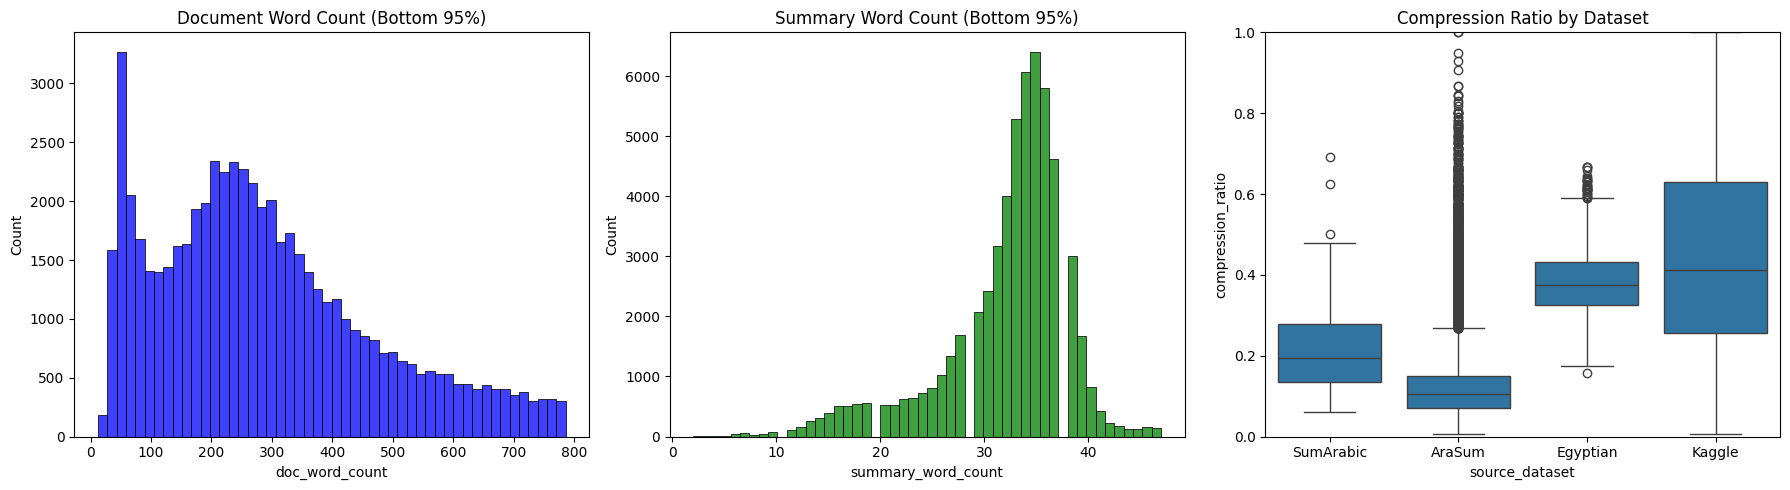

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

master_df['doc_word_count'] = master_df['document'].apply(lambda x: len(str(x).split()))
master_df['summary_word_count'] = master_df['summary'].apply(lambda x: len(str(x).split()))

master_df['compression_ratio'] = master_df['summary_word_count'] / master_df['doc_word_count']

master_df.replace([np.inf, -np.inf], np.nan, inplace=True)
master_df.dropna(subset=['compression_ratio'], inplace=True)

print("--- Sequence Length Statistics ---")
display(master_df[['doc_word_count', 'summary_word_count', 'compression_ratio']].describe())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

doc_95 = master_df['doc_word_count'].quantile(0.95)
sns.histplot(master_df[master_df['doc_word_count'] < doc_95]['doc_word_count'], bins=50, ax=axes[0], color='blue')
axes[0].set_title('Document Word Count (Bottom 95%)')

sum_95 = master_df['summary_word_count'].quantile(0.95)
sns.histplot(master_df[master_df['summary_word_count'] < sum_95]['summary_word_count'], bins=50, ax=axes[1], color='green')
axes[1].set_title('Summary Word Count (Bottom 95%)')

sns.boxplot(x='source_dataset', y='compression_ratio', data=master_df, ax=axes[2])
axes[2].set_title('Compression Ratio by Dataset')
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.show()

# **Our EDA Findings:**

---



Document Lengths: 75% of our documents are under 425 words. We will set the encoder's MAX_TEXT_LEN to 400 to optimize memory.

Summary Lengths: Our target summaries are very consistent (mostly 30-36 words). We will set the decoder's MAX_SUMMARY_LEN to 50.

Dataset Variance: The AraSum dataset is highly compressive (summaries are ~10% of the text length), while the Egyptian and Kaggle datasets are much less compressed (~40%).

Anomalies: We discovered invalid rows where summaries are actually longer than the original text (ratio > 1.0). We will filter these out before training.


# **Data Preprocessing**

In [27]:
import re
import pandas as pd
import numpy as np

master_df['doc_word_count'] = master_df['document'].apply(lambda x: len(str(x).split()))
master_df['summary_word_count'] = master_df['summary'].apply(lambda x: len(str(x).split()))
master_df['ratio'] = master_df['summary_word_count'] / master_df['doc_word_count']
master_df = master_df[(master_df['ratio'] < 1.0) & (master_df['ratio'] > 0.05)].copy()

def advanced_clean(text):
    if not isinstance(text, str): return ""
    text = re.sub(r'http\S+|[a-zA-Z]', '', text)
    text = re.sub(r'[\u064B-\u065F\u0640]', '', text)
    text = re.sub("[إأآا]", "ا", text)
    text = re.sub("ى", "ي", text)
    text = re.sub("ة", "ه", text)
    text = re.sub(r'^ال', '', text)
    text = re.sub(r'^وبال', '', text)

    return re.sub(r'\s+', ' ', re.sub(r'([^\w\s\ا-ي0-9\.،؟])', r' ', text)).strip()


master_df['clean_doc'] = master_df['document'].apply(advanced_clean)
master_df['clean_summary'] = master_df['summary'].apply(lambda x: f"sostok {advanced_clean(x)} eostok")

clean_df = master_df[
    (master_df['clean_doc'].str.split().str.len().between(1, 400)) &
    (master_df['clean_summary'].str.split().str.len().between(3, 50))
][['clean_doc', 'clean_summary']].copy()

print(f"clean samples: {len(clean_df)}")

clean samples: 40329


In [28]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

x_train, x_temp, y_train, y_temp = train_test_split(
    clean_df['clean_doc'], clean_df['clean_summary'], test_size=0.2, random_state=42)
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.5, random_state=42)

VOCAB_SIZE = 40000
x_tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<UNK>')
x_tokenizer.fit_on_texts(list(x_train))

y_tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<UNK>')
y_tokenizer.fit_on_texts(list(y_train))

x_tr_seq = pad_sequences(x_tokenizer.texts_to_sequences(x_train), maxlen=400, padding='post')
x_val_seq = pad_sequences(x_tokenizer.texts_to_sequences(x_val), maxlen=400, padding='post')
y_tr_seq = pad_sequences(y_tokenizer.texts_to_sequences(y_train), maxlen=50, padding='post')
y_val_seq = pad_sequences(y_tokenizer.texts_to_sequences(y_val), maxlen=50, padding='post')

print(f"Encoder Input Shape: {x_tr_seq.shape}")

total_words = len(x_tokenizer.word_index)
print(f"\nTotal unique words: {total_words}")

total_words = len(x_tokenizer.word_index)
print(f"\nTotal unique words in Encoder Vocab: {total_words}")

Encoder Input Shape: (32263, 400)

Total unique words: 235426

Total unique words in Encoder Vocab: 235426
